In [1]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

In [3]:
#  Training data using Titanic CSV file

train = pd.read_csv(r'C:\Users\Hp\.vscode\Journey to the BEST\Week 1\train.csv')

train['Sex'] = train['Sex'].map({'male':0,'female':1})
train['Age'] = train['Age'].fillna(train['Age'].median())
train['Fare'] = train['Fare'].fillna(train['Fare'].median())
train['Embarked'] = train['Embarked'].fillna('S').map({'S':0,'C':1,'Q':2})
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1

FEATURES = ['Pclass','Sex','Age','Fare','Embarked','FamilySize']
X = train[FEATURES].values
y = train['Survived'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

pipe.fit(X_train,y_train)

print(f"Train: {pipe.score(X_train,y_train):.3f}")
print(f"Test: {pipe.score(X_test,y_test):.3f}")

#  CROSS VALIDATION - prevents leakage

cv_scores = cross_val_score(pipe,X,y,cv=5, scoring='accuracy')
print(f"\n5-fold CV: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Per fold:  {cv_scores.round(3)}")

Train: 0.802
Test: 0.799

5-fold CV: 0.792 ± 0.013
Per fold:  [0.782 0.798 0.787 0.781 0.815]


=== Fair model comparison (same preprocessing) ===

Logistic Regression   : 0.792 ± 0.013
Random Forest         : 0.810 ± 0.031
SVM                   : 0.825 ± 0.019


C:\Users\Hp\AppData\Local\Temp\ipykernel_21300\292934366.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(results.values(), labels=results.keys())


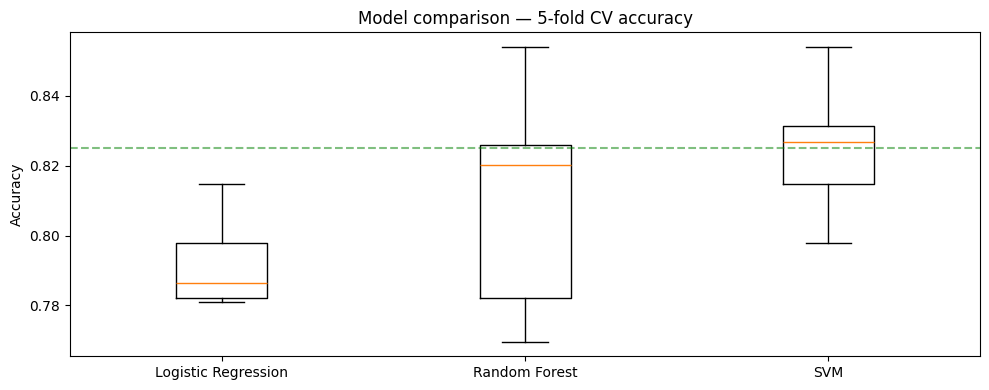

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Same preprocessing, different models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100,random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
}

print("=== Fair model comparison (same preprocessing) ===\n")
results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  model)
    ])
    scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
    results[name] = scores
    print(f"{name:22s}: {scores.mean():.3f} ± {scores.std():.3f}")

# Plot comparison
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot(results.values(), labels=results.keys())
ax.set_title('Model comparison — 5-fold CV accuracy')
ax.set_ylabel('Accuracy')
ax.axhline(y=max(r.mean() for r in results.values()),color='green', linestyle='--', alpha=0.5, label='Best mean')
plt.tight_layout()
plt.show()

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# Loading raw data
train_raw = pd.read_csv(r'C:\Users\Hp\.vscode\Journey to the BEST\Week 1\train.csv')
train_raw['FamilySize'] = train_raw['SibSp'] + train_raw['Parch'] + 1

# Define columns by type
numeric_features     = ['Age', 'Fare', 'FamilySize', 'Pclass']
categorical_features = ['Sex', 'Embarked']

X_raw = train_raw[numeric_features + categorical_features]
y_raw = train_raw['Survived']

# ── Preprocessing for numeric columns ────────────────────
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # fill missing
    ('scaler',  StandardScaler()),                  # normalise
])

# ── Preprocessing for categorical columns ─────────────────
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  
    ('encoder', OrdinalEncoder(                          
                handle_unknown='use_encoded_value',
                unknown_value=-1)),
])

# ── Combine both preprocessors ────────────────────────────
preprocessor = ColumnTransformer([
    ('num', numeric_transformer,     numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

# ── Full pipeline: preprocess + model ─────────────────────
full_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

# ── Train and evaluate ────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

full_pipe.fit(X_tr, y_tr)
print(f"Train: {full_pipe.score(X_tr, y_tr):.3f}")
print(f"Test:  {full_pipe.score(X_te, y_te):.3f}")

cv = cross_val_score(full_pipe, X_raw, y_raw, cv=5)
print(f"CV:    {cv.mean():.3f} ± {cv.std():.3f}")

Train: 0.803
Test:  0.804
CV:    0.790 ± 0.014


In [ ]:
from sklearn.model_selection import GridSearchCV

# Searching over BOTH preprocessing and model params

param_grid = {
    'model__C':            [0.01, 0.1, 1, 10],     # LR regularisation
    'model__max_iter':     [500, 1000],
    'preprocessor__num__imputer__strategy': ['mean', 'median'],
}

grid = GridSearchCV(full_pipe, param_grid,
                    cv=5, scoring='accuracy',
                    n_jobs=-1, verbose=1)
grid.fit(X_raw, y_raw)

print(f"\nBest params: {grid.best_params_}")
print(f"Best CV:     {grid.best_score_:.3f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best params: {'model__C': 0.1, 'model__max_iter': 500, 'preprocessor__num__imputer__strategy': 'mean'}
Best CV:     0.791
